In [172]:
from sklearn.exceptions import DataConversionWarning
from statsmodels.tools.sm_exceptions import ValueWarning
import warnings

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)
warnings.filterwarnings("ignore", category=ValueWarning)

In [173]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Setup

In [174]:
import pandas as pd
import numpy as np

data = pd.read_csv("/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /Data Set/vcb_Training_Data.csv")
"""
data = data.set_index("Date")
"""
data.rename(columns={'Unnamed: 0': 'time'}, inplace=True)
data.set_index("time", inplace=True)

df = data.copy()

training_data = df.loc[:, ~df.columns.isin(["target", "strength target", "regression target"])].copy()
target= df.loc[:, ["target"]].copy()

display(training_data.shape, target.shape)
display(data)

(2367, 108)

(2367, 1)

,open,high,low,close,volume,vnindex,vn30,hnx,gold,oil,...,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr,target
time,,,,,,,,,,,,,,,,,,,,,
2015-11-16,14.25,14.40,14.19,14.25,426970.0,609.21,619.14,81.05,1083.699951,43.580002,...,0.881119,-0.207515,-3.104510,3.271574,-6.376084,14.115983,-1.556971,-1.569219,11.741835,1.0
2015-11-17,14.25,14.52,14.22,14.28,448710.0,605.05,614.39,81.14,1068.699951,43.570000,...,0.790877,-0.360965,-2.384450,2.140370,-4.524819,14.207312,-1.294033,-1.302479,10.808709,1.0
2015-11-18,14.22,14.37,14.22,14.28,302580.0,603.34,612.25,81.36,1068.800049,44.139999,...,0.683069,-0.431232,-7.209824,0.270331,-7.480155,14.277276,0.436999,0.436047,11.041991,0.0
2015-11-19,14.34,14.34,14.19,14.22,359250.0,601.90,609.05,81.24,1078.000000,44.180000,...,0.571935,-0.444538,-12.017176,-2.187171,-9.830006,14.299412,1.377810,1.368405,11.041991,0.0
2015-11-20,14.22,14.31,14.22,14.22,268060.0,604.46,611.16,81.59,1076.400024,44.660000,...,0.474137,-0.391191,-15.337819,-4.817300,-10.520519,14.314468,1.502146,1.490975,10.575428,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-21,63.30,65.00,63.30,64.20,9639300.0,1688.00,1874.91,284.39,3336.899902,67.669998,...,-0.171033,0.423546,10.083656,2.077334,8.006321,61.427762,0.000000,0.000000,389.891135,1.0
2025-08-22,64.00,67.20,63.70,64.60,18944300.0,1645.47,1814.02,272.48,3374.399902,67.730003,...,-0.056238,0.459181,9.402578,3.542383,5.860195,61.430353,-0.161031,-0.161160,399.222395,0.0
2025-08-25,65.80,65.80,63.40,63.60,7750800.0,1614.03,1783.12,266.58,3373.800049,68.800003,...,0.063700,0.479751,13.820402,5.597987,8.222415,61.439830,1.290323,1.282069,402.332815,1.0


In [175]:
df1 = data.copy()
arr = df1.corrwith(df1.target)

print("Corr:")
print( arr.loc[arr > 0].sort_values(ascending=False) )

print("Var:")
print( df1.var().loc[arr > 0].sort_values(ascending=False) )

Corr:
target                   1.000000
volume_cmf               0.054870
volatility_ui            0.040543
volume_fi                0.034866
trend_adx                0.033461
volume_nvi               0.033195
monday_morning           0.032848
trend_aroon_down         0.031759
momentum_uo              0.030206
volatility_kcw           0.029307
momentum_stoch           0.029076
momentum_wr              0.029076
volatility_bbw           0.029056
volatility_dcw           0.025225
momentum_roc             0.023950
momentum_stoch_signal    0.022943
volume_adi               0.019441
post_holiday_morning     0.017000
trend_vortex_ind_pos     0.015996
trend_vortex_ind_diff    0.015467
volume_em                0.010953
momentum_stoch_rsi       0.010612
trend_adx_neg            0.009952
momentum_stoch_rsi_d     0.009236
volume_sma_em            0.007106
momentum_stoch_rsi_k     0.006446
momentum_rsi             0.005976
volatility_kchi          0.005685
trend_kst_sig            0.005469
trend_ma

In [176]:
def data_split(split_percentage, df):

    assert 0 < split_percentage < 1, "split_percentage must be a float between 0 and 1 (exclusive)"
    
    split_index = int(len(df) * split_percentage)

    train_df = df.iloc[:split_index].copy()
    test_df = df.iloc[split_index:].copy()
    
    return train_df, test_df

X, Valid_set = data_split(split_percentage=0.8, df=training_data.reset_index(drop=True))
y, Valid_result = target.reset_index(drop=True).loc[X.index], target.reset_index(drop=True).loc[Valid_set.index]

## Model Evaluation:

In [177]:
def purged_kfold_split(X, n_splits=5, lookahead=5, embargo=0):
    fold_size = len(X) // n_splits
    for i in range(n_splits):
        test_start = i * fold_size
        test_end = (i + 1) * fold_size

        # Embargo
        embargo_start = test_end + 1
        embargo_end = embargo_start + embargo

        # Purge overlaps
        train_idx = list(range(0, test_start - lookahead)) + list(range(embargo_end, len(X)))
        test_idx = list(range(test_start, test_end))

        yield train_idx, test_idx

# Optimization:

In [178]:
#return_array = 'return'
return_array = 'log_return'

In [179]:
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from itertools import product

# --- Hyperparameter grid ---
#k_regimes_list = [i for i in range(2, 10)]
k_regimes_list = [2]
switching_trend_list = [True, False]
switching_variance_list = [True, False]

results = []

X_train_1 = X.copy()
y_train_1 = y.copy()

for k, st, sv in product(k_regimes_list, switching_trend_list, switching_variance_list):
    aic_array = []
    bic_array = []
    llf_array = []
    for fold_idx, (train_idx, test_idx) in enumerate(purged_kfold_split(X_train_1.copy())):
        X_train, X_test = X_train_1.iloc[train_idx], X_train_1.iloc[test_idx]
        y_train, y_test = y_train_1.iloc[train_idx], y_train_1.iloc[test_idx]
        
        try:
            #return_array = 'log_return'
            #return_array = 'return'
            core_array_estimate = (X_train[return_array] - X_train[return_array].mean()) / X_train[return_array].std()
            
            exog_cols = [] #['vnindex', 'vn30', 'gold', 'oil'] 
            exog = X_train[exog_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).values
            
            model = MarkovRegression(
                endog=core_array_estimate,  # must be 1D
                k_regimes=k,
                trend='c',
                exog=exog,
                switching_trend=st,
                switching_exog=False,  # keep exog shared for simplicity
                switching_variance=sv
            )
            res = model.fit(disp=False, maxiter=500)
            
            aic_array.append(res.aic)
            bic_array.append(res.bic)
            llf_array.append(res.llf)
            
            print(f"Done: regimes={k}, trend={st}, var={sv} | AIC={res.aic:.1f}, BIC={res.bic:.1f}")
        except Exception as e:
            print(f"Failed: regimes={k}, trend={st}, var={sv} | {e}")

    results.append({
            'k_regimes': k,
            'switching_trend': st,
            'switching_variance': sv,
            'aic': np.mean(aic_array),
            'bic': np.mean(bic_array),
            'loglik': np.mean(llf_array)
        })

# Convert results to DataFrame and pick best by BIC or AIC
results_df = pd.DataFrame(results)
best_model_idx = results_df['bic'].idxmin()
best_params = results_df.loc[best_model_idx]
print("\nBest model by BIC:")
print(best_params)

Done: regimes=2, trend=True, var=True | AIC=4032.3, BIC=4064.3
Done: regimes=2, trend=True, var=True | AIC=4073.1, BIC=4105.0
Done: regimes=2, trend=True, var=True | AIC=4014.1, BIC=4046.0
Done: regimes=2, trend=True, var=True | AIC=4015.7, BIC=4047.6
Done: regimes=2, trend=True, var=True | AIC=4012.3, BIC=4044.2
Done: regimes=2, trend=True, var=False | AIC=4305.5, BIC=4332.2
Done: regimes=2, trend=True, var=False | AIC=4291.4, BIC=4318.0
Done: regimes=2, trend=True, var=False | AIC=4291.4, BIC=4318.0
Done: regimes=2, trend=True, var=False | AIC=4291.4, BIC=4318.0
Done: regimes=2, trend=True, var=False | AIC=4291.4, BIC=4318.0
Done: regimes=2, trend=False, var=True | AIC=4036.8, BIC=4063.4
Done: regimes=2, trend=False, var=True | AIC=4076.1, BIC=4102.7
Done: regimes=2, trend=False, var=True | AIC=4019.2, BIC=4045.8
Done: regimes=2, trend=False, var=True | AIC=4017.8, BIC=4044.4
Done: regimes=2, trend=False, var=True | AIC=4014.2, BIC=4040.8
Done: regimes=2, trend=False, var=False | AIC

## File Saving:

In [180]:
best_params

k_regimes                       2
switching_trend             False
switching_variance           True
aic                   4032.829472
bic                   4059.428792
loglik               -2011.414736
Name: 2, dtype: object

In [184]:
k = int(best_params['k_regimes'])
st = bool(best_params['switching_trend'])
sv = bool(best_params['switching_variance'])

df = pd.concat([X, Valid_set], axis=0).copy()

core_array_estimate = (df[return_array] - df[return_array].mean()) / df[return_array].std()

exog_cols = [] #['vnindex', 'vn30', 'gold', 'oil'] 
exog = df[exog_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)

msm_model = MarkovRegression(
    endog=core_array_estimate,  # must be 1D
    k_regimes=k,
    trend='c',
    exog=exog,
    switching_trend=st,
    switching_exog=False,  # keep exog shared for simplicity
    switching_variance=sv
)

msm_model

In [185]:
import joblib

# Save model and threshold together
package = {
    "endog": core_array_estimate,  # must be 1D
    "k_regimes": k,
    "trend": 'c',
    "exog": exog,
    "switching_trend": st,
    "switching_exog": False,  # keep exog shared for simplicity
    "switching_variance": sv
}
joblib.dump(package, '/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/msm_model_with_threshold.pkl')

['/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/msm_model_with_threshold.pkl']

# Test 1

## Fit a k-Regime MSM

In [142]:
df = data.copy()

In [ ]:
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from sklearn.preprocessing import StandardScaler

exog_cols = [] #["vnindex", "vn30", "gold", "oil"]
exog = None
if exog_cols:
    exog = df[exog_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).values

'''
model = MarkovRegression(
    endog=core_array_estimate,  # must be 1D
    k_regimes=5,
    trend='c',
    exog=exog,
    switching_trend=st,
    switching_exog=False,  # keep exog shared for simplicity
    switching_variance=sv
)
'''
model = msm_model

res = model.fit(disp=False, maxiter=200)

# 4) Get regime probabilities (smoothed) and hard labels
#    smoothed_marginal_probabilities returns an array (T x k_regimes)
proba = res.smoothed_marginal_probabilities.values
proba = np.asarray(proba) if isinstance(proba, list) else proba  # guard for older versions

# Align to index
for i in range(model.k_regimes):
    df[f"regime_prob_{i}"] = proba[:, i]

df["regime"] = proba.argmax(axis=1).astype(int)

# 5) (Nice to have) transition matrix & expected durations
k = res.k_regimes  
trans_params = res.params[-(k * (k - 1)):].values
trans_params = trans_params.reshape(k, k - 1)
trans_mat = np.zeros((k, k))
for i in range(k):
    # softmax over (k-1) free parameters + implicit zero
    row = np.append(trans_params[i], 0.0)  
    exp_row = np.exp(row - np.max(row))  # numerically stable softmax
    trans_mat[i] = exp_row / exp_row.sum()

expected_durations = res.expected_durations

print("Converged:", res.mle_retvals.get("converged", None))
print("LogLik:", res.llf)

if trans_mat is not None:
    print("Transition matrix (rows: from, cols: to):\n", trans_mat)
if expected_durations is not None:
    print("Expected regime durations (in time steps):", expected_durations)

# 6) Now df has regime features for your classifier:
#    ['regime', 'regime_prob_0', 'regime_prob_1']   
#    You can merge these into your ML feature table by index.
df_out = df[["return", "regime", "regime_prob_0", "regime_prob_1"]]
print(df_out.head())

Converged: True
LogLik: -3095.0213150969757
Transition matrix (rows: from, cols: to):
 [[0.57775565 0.42224435]
 [0.89141741 0.10858259]]
Expected regime durations (in time steps): [13.75194634  8.59105872]
            return  regime  regime_prob_0  regime_prob_1
time                                                    
2015-11-16    0.00       0       0.948672       0.051328
2015-11-17    0.03       0       0.969397       0.030603
2015-11-18    0.06       0       0.972549       0.027451
2015-11-19   -0.12       0       0.964412       0.035588
2015-11-20    0.00       0       0.947695       0.052305


## Visualize regimes

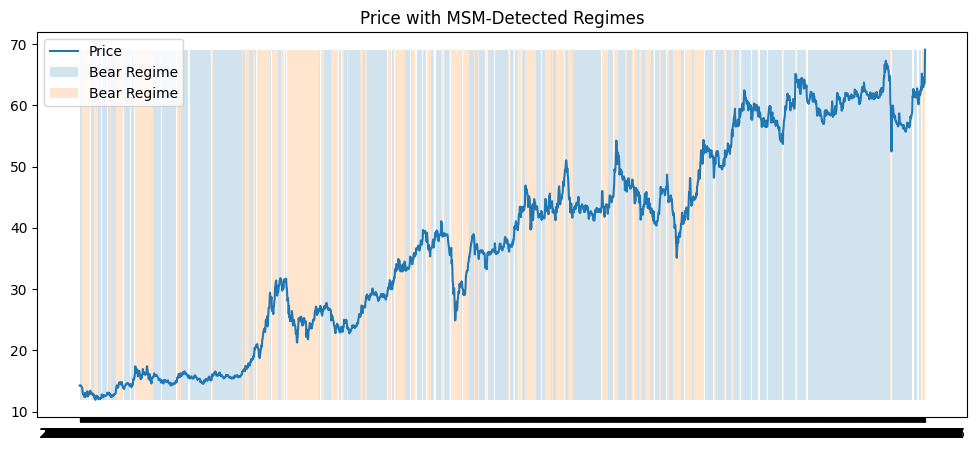

'\n# Plot smoothed probability\nplt.figure(figsize=(12,3))\nplt.plot(df[\'regime_prob\'], label=\'Smoothed Prob(Regime=1)\')\nplt.title("MSM Smoothed Regime Probabilities")\nplt.ylabel("Probability")\nplt.xlabel("Time")\nplt.show()\n'

In [144]:
plt.figure(figsize=(12,5))
plt.plot(df['close'], label='Price')
for i in df['regime'].unique():
    plt.fill_between(df.index, df['close'].min(), df['close'].max(), 
                 where=df['regime']==i, alpha=0.2, label='Bear Regime')
    
plt.title("Price with MSM-Detected Regimes")
plt.legend()
plt.show()

'''
# Plot smoothed probability
plt.figure(figsize=(12,3))
plt.plot(df['regime_prob'], label='Smoothed Prob(Regime=1)')
plt.title("MSM Smoothed Regime Probabilities")
plt.ylabel("Probability")
plt.xlabel("Time")
plt.show()
'''

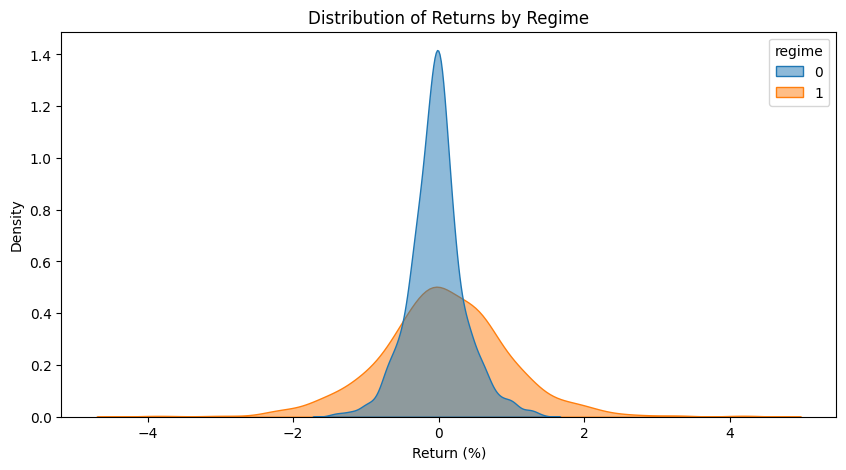

In [145]:
import seaborn as sns

proba = res.smoothed_marginal_probabilities
proba = np.asarray(proba) if isinstance(proba, list) else proba  # guard for older versions
#regimes = proba.argmax(axis=1).astype(int)
regimes = proba.idxmax(axis=1).astype(int)

df_regime = pd.DataFrame({"return": df['return'].reset_index(drop=True), "regime": regimes})

# --- 5. Plot distributions ---
plt.figure(figsize=(10,5))
sns.kdeplot(data=df_regime, x="return", hue="regime", fill=True, common_norm=False, alpha=0.5)
plt.title("Distribution of Returns by Regime")
plt.xlabel("Return (%)")
plt.ylabel("Density")
plt.show()

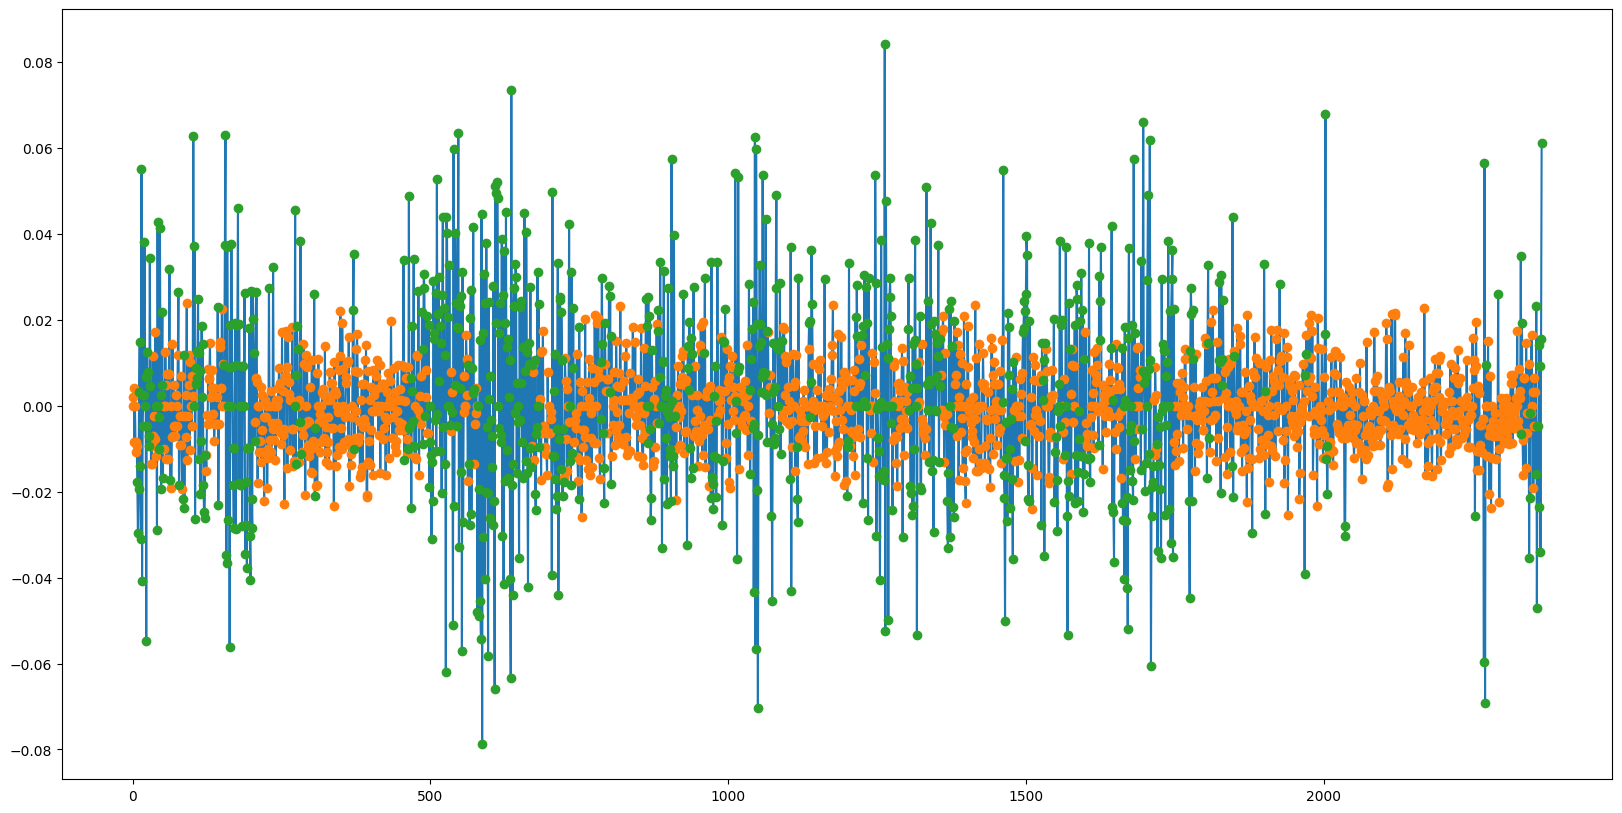

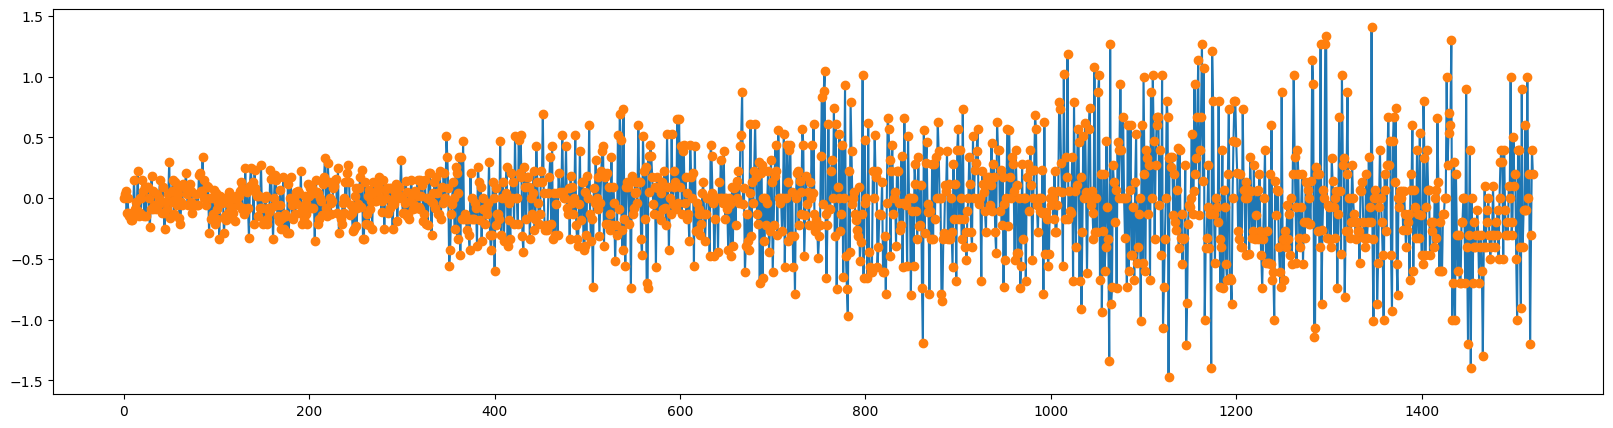

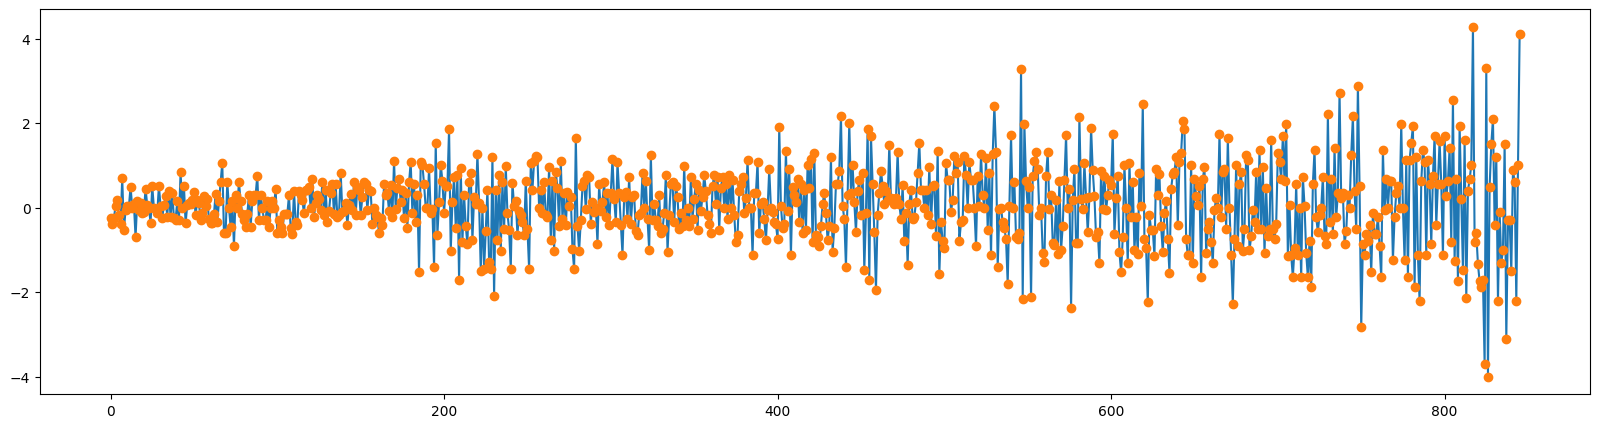

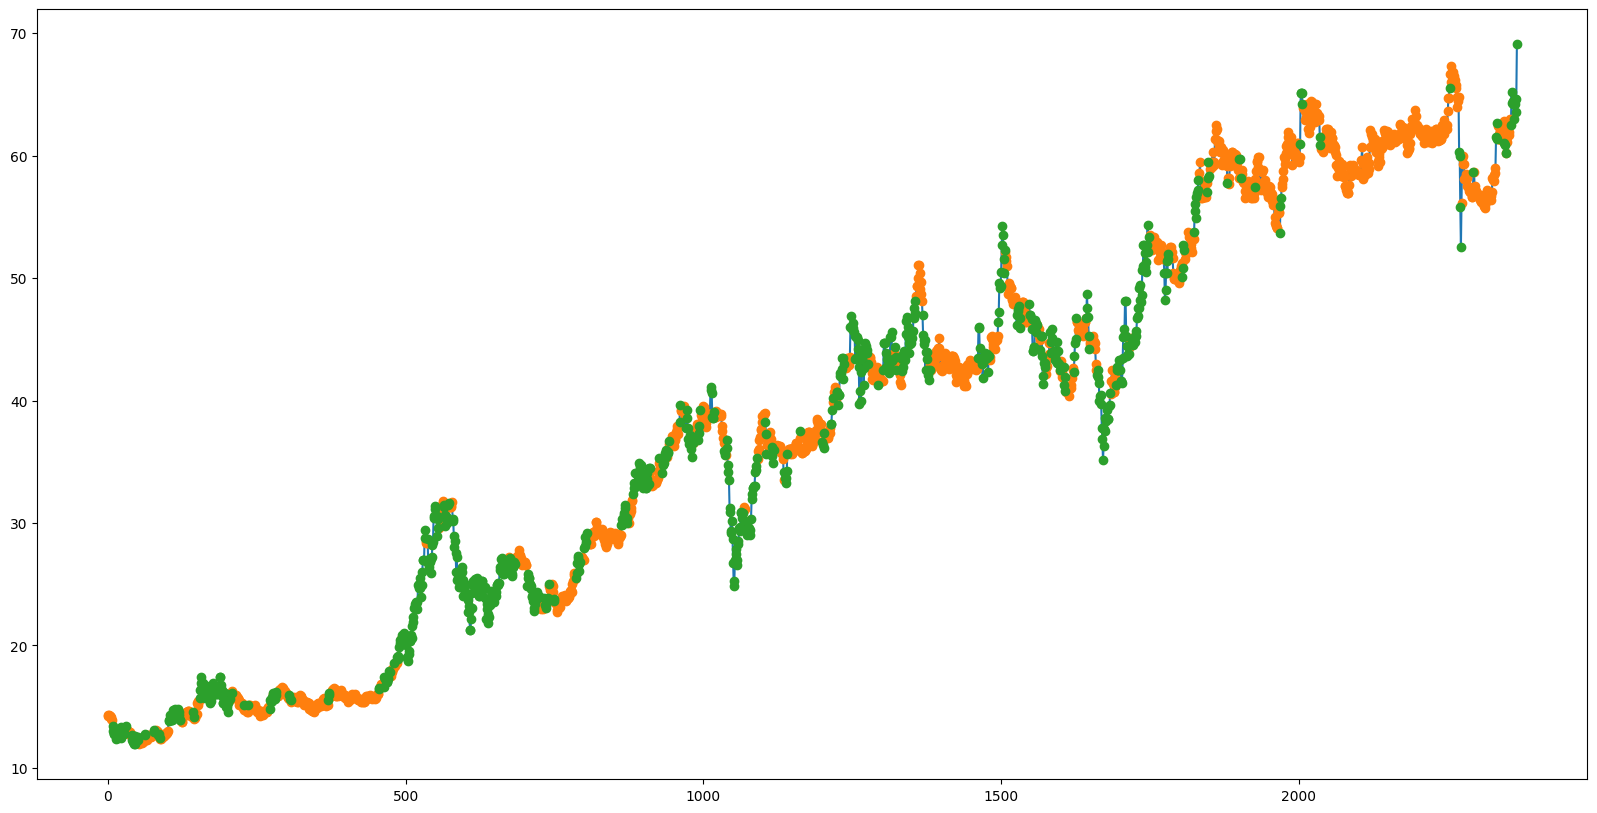

In [146]:
df2 = df.dropna().reset_index(drop=True)

plt.figure(figsize=(20,10))
plt.plot(df2['log_return'])
for regime in df2['regime'].unique():
    plt.plot(df2.loc[df2['regime'] == regime, ['log_return']], 'o')
plt.show()

for regime in df2['regime'].unique():
    plt.figure(figsize=(20, 5))
    plt.plot(df2.loc[df2['regime'] == regime, ['return']].reset_index(drop=True))
    plt.plot(df2.loc[df2['regime'] == regime, ['return']].reset_index(drop=True), 'o')
    plt.show()

plt.figure(figsize=(20,10))
plt.plot(df2['close'])
for regime in df2['regime'].unique():
    plt.plot(df2.loc[df2['regime'] == regime, ['close']], 'o')
plt.show()

## Regimes Info:

In [147]:
df["regime"].unique()

array([0, 1])

In [148]:
from statsmodels.tsa.stattools import acf

# --- Mean & Std (volatility proxy) ---
regime_stats = df.groupby("regime")["return"].agg(["mean", "std"])

# --- Autocorrelation per regime ---
def compute_acf(series, nlags=3):
    # Drop NA and require minimum length
    if len(series.dropna()) < nlags + 1:
        return [np.nan] * nlags
    return acf(series.dropna(), nlags=nlags, fft=False)[1:]  # skip lag 0

acf_results = (
    df.groupby("regime")["return"]
      .apply(lambda x: compute_acf(x, nlags=3))
      .apply(pd.Series)  # expand list into columns
)
    
acf_results.columns = [f"acf_lag{lag}" for lag in range(1, len(acf_results.columns)+1)]

# --- Duration per regime ---
P = trans_mat.copy()
durations = 1 / (1 - np.diag(P))
durations_df = pd.DataFrame({
    "expected_duration": durations
})

# --- Combine everything ---
regime_stats = pd.concat([regime_stats, acf_results, durations_df], axis=1)
print(regime_stats)

       mean       std  acf_lag1  acf_lag2  acf_lag3  expected_duration
0 -0.029152  0.379294  0.014755 -0.004496  0.004102           2.368297
1  0.065426  0.902119 -0.082480  0.054206 -0.006032           1.121809


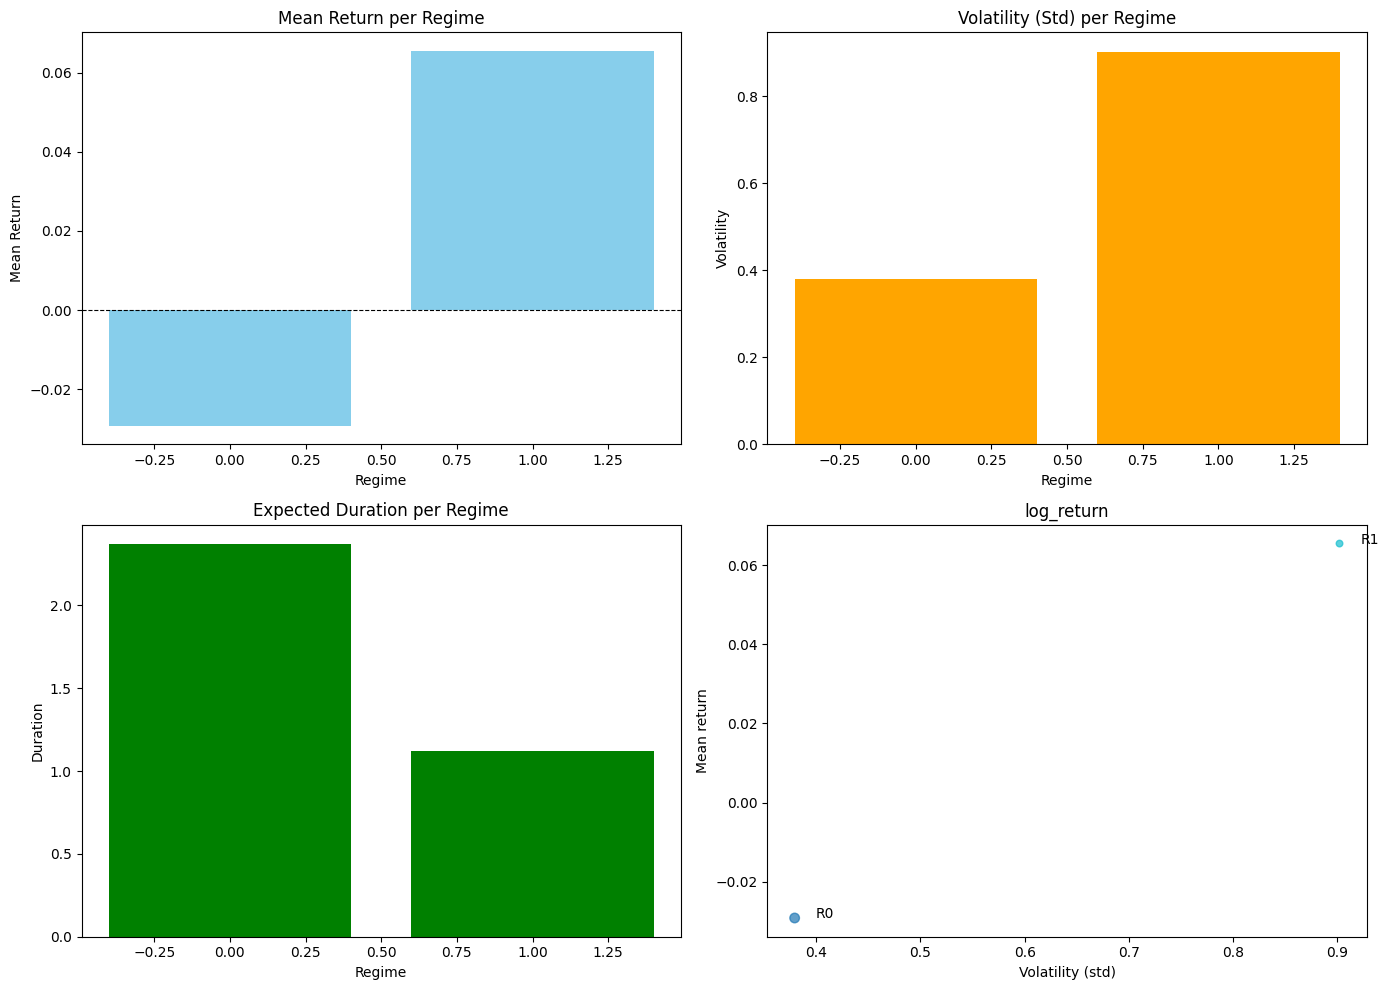

In [149]:
# Re-import necessary libraries after reset
import pandas as pd
import matplotlib.pyplot as plt

# Recreate the regime stats DataFrame
df1 = regime_stats.copy()
df1['regime'] = range(len(df1))

# Multiple plots to show regime properties more clearly
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# --- 1. Mean return vs Regime ---
axes[0,0].bar(df1["regime"], df1["mean"], color="skyblue")
axes[0,0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0,0].set_title("Mean Return per Regime")
axes[0,0].set_xlabel("Regime")
axes[0,0].set_ylabel("Mean Return")

# --- 2. Volatility vs Regime ---
axes[0,1].bar(df1["regime"], df1["std"], color="orange")
axes[0,1].set_title("Volatility (Std) per Regime")
axes[0,1].set_xlabel("Regime")
axes[0,1].set_ylabel("Volatility")

# --- 3. Expected Duration vs Regime ---
axes[1,0].bar(df1["regime"], df1["expected_duration"], color="green")
axes[1,0].set_title("Expected Duration per Regime")
axes[1,0].set_xlabel("Regime")
axes[1,0].set_ylabel("Duration")

# --- 4. Mean vs Volatility scatter with bubble size = duration ---
scatter = axes[1,1].scatter(df1["std"], df1["mean"], s=df1["expected_duration"]*20,
                            c=df1["regime"], cmap="tab10", alpha=0.7)
for i, row in df1.iterrows():
    axes[1,1].text(row["std"]+0.02, row["mean"], f'R{int(row["regime"])}')
axes[1,1].set_xlabel("Volatility (std)")
axes[1,1].set_ylabel("Mean return")
axes[1,1].set_title("Regime Map (Mean vs Volatility, bubble=Duration)")

plt.title(f"{return_array}")
plt.tight_layout()
plt.show()

In [150]:
import numpy as np
from scipy import stats

# Example: two sample arrays
returns_regime0 = df.loc[df["regime"] == 0, ['return']]
returns_regime1 = df.loc[df["regime"] == 1, ['return']]

# -------------------------------
# Idea 1: Are they statistically different?
# -------------------------------
ks_stat, ks_p = stats.ks_2samp(returns_regime0, returns_regime1)
levene_stat, levene_p = stats.levene(returns_regime0, returns_regime1)

print("KS Test: stat=%.3f, p=%.3f" % (ks_stat, ks_p))
print("Levene Test (variance): stat=%.3f, p=%.3f" % (levene_stat, levene_p))

# -------------------------------
# Idea 2: How separable are they?
# -------------------------------
# Bhattacharyya distance
def bhattacharyya(p, q, bins=50):
    hist_p, _ = np.histogram(p, bins=bins, density=True)
    hist_q, _ = np.histogram(q, bins=bins, density=True)
    hist_p = hist_p / np.sum(hist_p)
    hist_q = hist_q / np.sum(hist_q)
    bc = np.sum(np.sqrt(hist_p * hist_q))  # Bhattacharyya coefficient
    return -np.log(bc + 1e-12)  # distance

bd = bhattacharyya(returns_regime0, returns_regime1)

# Fisher’s Discriminant Ratio
mean0, mean1 = np.mean(returns_regime0), np.mean(returns_regime1)
var0, var1 = np.var(returns_regime0), np.var(returns_regime1)
fdr = (mean0 - mean1)**2 / (var0 + var1)

print("Bhattacharyya Distance:", bd)
print("Fisher’s Discriminant Ratio:", fdr)


KS Test: stat=0.241, p=0.000
Levene Test (variance): stat=497.110, p=0.000
Bhattacharyya Distance: 0.02624945942956854
Fisher’s Discriminant Ratio: return    0.00935
dtype: float64


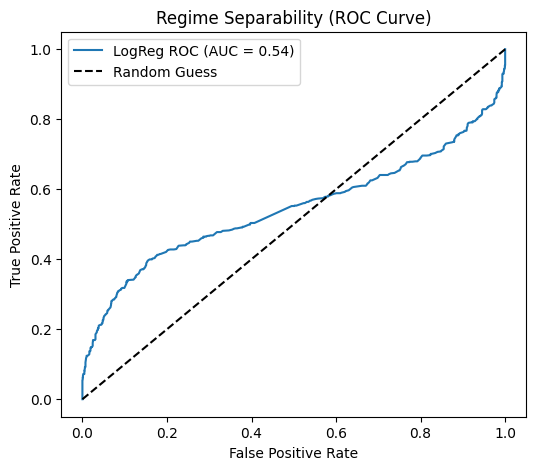

In [151]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression

# Create dataset
X = np.concatenate([returns_regime0, returns_regime1]).reshape(-1, 1)
y = np.array([0]*len(returns_regime0) + [1]*len(returns_regime1))

# Train a simple logistic regression classifier
clf = LogisticRegression()
clf.fit(X, y)
y_scores = clf.predict_proba(X)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y, y_scores)
auc = roc_auc_score(y, y_scores)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"LogReg ROC (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Regime Separability (ROC Curve)")
plt.legend()
plt.show()


# Testing 2:

## ML models import

In [163]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
import joblib

model_paths = ["knn_model_with_threshold.pkl", "logr_model_with_threshold.pkl", "rf_model_with_threshold.pkl", "xgb_model_with_threshold.pkl"]
model_names = ["KNNs", "LogR", "RF", "XGB"]
model_infor = {}

for name, path in zip(model_names, model_paths):
    model_infor[name] = joblib.load(f"/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/{path}")
    
for key, infor in model_infor.items():
    print(f"{key}: {display(infor['model'])} \n  Threshold: {infor['threshold']}")

KNeighborsClassifier(leaf_size=47, n_jobs=-1, n_neighbors=10, p=1,
                     weights='distance')

KNNs: None 
  Threshold: 0.003311573538144028


LogisticRegression(C=1.8727005942368125, class_weight='balanced',
                   l1_ratio=0.9507143064099162, max_iter=1000, random_state=42,
                   solver='saga')

LogR: None 
  Threshold: 0.5009190475828135


RandomForestClassifier(class_weight='balanced', max_depth=3,
                       max_features=0.8473033655253104, min_samples_leaf=2,
                       min_samples_split=4, n_estimators=99, n_jobs=-1,
                       random_state=42)

RF: None 
  Threshold: 0.3917139932551503


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.13949386065204183, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=2.9214464853521815, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=18.318092164684586,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=23, max_leaves=None,
              min_child_weight=39, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

XGB: None 
  Threshold: 0.333642225264517


## without MSM

In [156]:
from sklearn.metrics import f1_score, accuracy_score, classification_report

for name, infor in model_infor.items():
    
    model = infor["model"]
    
    # record in the train-set
    X_train_1 = X.loc[:, infor["feature set"]].copy()
    model.fit(X_train_1, y)
    
    # record in the test-set    
    X_test_1 = Valid_set.loc[:, infor["feature set"]].copy()
    y_pred = model.predict(X_test_1)
    
    print( f"{name}_f1_score: {f1_score(y_true=Valid_result, y_pred=y_pred)}" )
    print( f"{name}_accuracny_score: {accuracy_score(y_true=Valid_result, y_pred=y_pred)}" )
    print(np.unique(y_pred, return_counts=True))

KNNs_f1_score: 0.4106666666666667
KNNs_accuracny_score: 0.5337552742616034
(array([0., 1.]), array([282, 192]))
LogR_f1_score: 0.5570776255707762
LogR_accuracny_score: 0.3860759493670886
(array([1.]), array([474]))
RF_f1_score: 0.4625
RF_accuracny_score: 0.45569620253164556
(array([0., 1.]), array([177, 297]))
XGB_f1_score: 0.5570776255707762
XGB_accuracny_score: 0.3860759493670886
(array([1]), array([474]))


## with MSM:

In [168]:
best_params

k_regimes                       2
switching_trend             False
switching_variance           True
aic                   4032.829472
bic                   4059.428792
loglik               -2011.414736
Name: 2, dtype: object

In [169]:
k = int(best_params['k_regimes'])
st = bool(best_params['switching_trend'])
sv = bool(best_params['switching_variance'])

In [170]:
from sklearn.metrics import f1_score, accuracy_score

X_train_1 = X.copy()
X_test_1 = Valid_set.copy()

res = msm_model.fit(disp=False, maxiter=500)
proba = res.smoothed_marginal_probabilities
proba = np.asarray(proba) if isinstance(proba, list) else proba  # guard for older versions
regimes = proba.idxmax(axis=1).astype(int)

train_regime, test_regime = regimes[X_train_1.index], regimes[X_test_1.index]

the_collab_ypred = {}
for regime in test_regime.unique():
    the_collab_ypred[f"regime: {regime}"] = []
    the_collab_ypred[f"regime score: {regime}"] = []
    
for name, infor in model_infor.items():
    
    model = infor["model"]
    # record in the train-set
    X_train = X.loc[:, infor["feature set"]].copy()
    # record in the test-set
    X_test = Valid_set.loc[:, infor["feature set"]].copy()
    
    print(f"model -- {name}:")
    
    the_final_ypred = np.zeros(len(X_test))
    for regime in test_regime.unique():
        
        X_train_res, y_train_res = X_train.loc[train_regime == regime], y.loc[train_regime == regime].copy()
        X_test_res, y_test_res = X_test.loc[test_regime == regime], Valid_result.loc[test_regime == regime].copy()

        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_test_res)
        ''' 
        y_proba = model.predict_proba(X_test_res)[:, 1]
        y_pred = np.where(y_proba >= infor['threshold'], 1, 0)
        '''
        
        the_final_ypred[test_regime == regime] = y_pred
        
        the_collab_ypred[f"regime: {regime}"].append(y_pred)
        the_collab_ypred[f"regime score: {regime}"].append(f1_score(y_true=y_test_res, y_pred=y_pred))

        print()
        print(f"REGIME: {regime}")
        print(f"Train: {np.unique(y_train_res, return_counts=True)}")
        print(f"Test: {np.unique(y_test_res, return_counts=True)}")
        print(f"prediction: {np.unique(y_pred, return_counts=True)} -- F1_Score: {f1_score(y_true=y_test_res, y_pred=y_pred)} -- Accurancy: {accuracy_score(y_true=y_test_res, y_pred=y_pred)}")

    print()
    print(f"Train: {np.unique(y, return_counts=True)}")
    print(f"Test: {np.unique(Valid_result, return_counts=True)}")
    print(f"prediction: {np.unique(the_final_ypred, return_counts=True)} -- F1_Score: {f1_score(y_true=Valid_result, y_pred=the_final_ypred)} -- Accurancy: {accuracy_score(y_true=Valid_result, y_pred=the_final_ypred)}")
    print(len(Valid_result), len(the_final_ypred))
    print()
    print()

model -- KNNs:

REGIME: 0
Train: (array([0., 1.]), array([611, 473]))
Test: (array([0., 1.]), array([270, 167]))
prediction: (array([0., 1.]), array([276, 161])) -- F1_Score: 0.39634146341463417 -- Accurancy: 0.5469107551487414

REGIME: 1
Train: (array([0., 1.]), array([420, 389]))
Test: (array([0., 1.]), array([21, 16]))
prediction: (array([0., 1.]), array([20, 17])) -- F1_Score: 0.42424242424242425 -- Accurancy: 0.4864864864864865

Train: (array([0., 1.]), array([1031,  862]))
Test: (array([0., 1.]), array([291, 183]))
prediction: (array([0., 1.]), array([296, 178])) -- F1_Score: 0.3988919667590028 -- Accurancy: 0.5421940928270043
474 474


model -- LogR:

REGIME: 0
Train: (array([0., 1.]), array([611, 473]))
Test: (array([0., 1.]), array([270, 167]))
prediction: (array([0.]), array([437])) -- F1_Score: 0.0 -- Accurancy: 0.6178489702517163

REGIME: 1
Train: (array([0., 1.]), array([420, 389]))
Test: (array([0., 1.]), array([21, 16]))
prediction: (array([1.]), array([37])) -- F1_Score

In [171]:
the_final_ypred = np.zeros(len(Valid_result))
for regime in test_regime.unique():
    max_score = 0
    for item_index, item_score in enumerate(the_collab_ypred[f"regime score: {regime}"]):
        if item_score > max_score and len(np.unique(the_collab_ypred[f'regime: {regime}'][item_index])) > 1:
            max_score = item_score
            indx = item_index
    
    the_final_ypred[test_regime == regime] = the_collab_ypred[f'regime: {regime}'][indx]
    print(f"{regime}: {the_collab_ypred[f"regime score: {regime}"][indx]}")
    print( np.unique(the_collab_ypred[f"regime: {regime}"][indx], return_counts=True) )
    
print()
print(f"The Collaboration") 
print(f"Train: {np.unique(y, return_counts=True)}")
print(f"Test: {np.unique(Valid_result, return_counts=True)}")
print(f"prediction: {np.unique(the_final_ypred, return_counts=True)} -- F1_Score: {f1_score(y_true=Valid_result, y_pred=the_final_ypred)} -- Accurancy: {accuracy_score(y_true=Valid_result, y_pred=the_final_ypred)}")
print(len(Valid_result), len(the_final_ypred))
print(classification_report(y_true=Valid_result, y_pred=the_final_ypred))

0: 0.4020100502512563
(array([0., 1.]), array([206, 231]))
1: 0.5490196078431373
(array([0, 1]), array([ 2, 35]))

The Collaboration
Train: (array([0., 1.]), array([1031,  862]))
Test: (array([0., 1.]), array([291, 183]))
prediction: (array([0., 1.]), array([208, 266])) -- F1_Score: 0.41870824053452116 -- Accurancy: 0.44936708860759494
474 474
              precision    recall  f1-score   support

         0.0       0.57      0.41      0.48       291
         1.0       0.35      0.51      0.42       183

    accuracy                           0.45       474
   macro avg       0.46      0.46      0.45       474
weighted avg       0.49      0.45      0.45       474

